# 📚 Importing Libaries


In [2]:
# 📚 Core Libraries
import sys
import os
import time
import math
import random

# 🔢 Scientific & Graph Libraries
import numpy as np
import networkx as nx
from scipy.stats import poisson

# 📊 Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

# ⚙️ Dynamic Style Configuration
mpl_params = {
    "text.usetex": False,   # LaTeX text rendering
    "font.family": "serif", # Font style
    "figure.dpi": 120,      # Image resolution
    "axes.titlesize": 14,   # Title font size
    "axes.labelsize": 12    # Label font size
}
mpl.rcParams.update(mpl_params)


### 🔑 Random Number Generator (64-bit Mersenne Twister style)

In [1]:
# ============================================================
# 📌 Simulador SPP/Quantum — versão organizada
# ============================================================

import sys
import time
import os
import math
import random
import numpy as np
import networkx as nx
from scipy.stats import poisson

# ============================================================
# 🎯 ESTRATÉGIAS DE ATAQUE (HUB / CLOSENESS / BETWEENNESS / RANDOM)
# ============================================================

def genrand64_int64():
    """Gera um inteiro pseudoaleatório de 64 bits (placeholder via random)."""
    return random.getrandbits(64)

def genrand64_real3():
    """Gera float em [0,1) a partir de um inteiro de 64 bits."""
    return genrand64_int64() / float(1 << 64)

def random_attack_node(N: int) -> int:
    """
    Seleciona um nó aleatório em [1, N].

    Parâmetros
    ----------
    N : int
        Número de nós.

    Retorna
    -------
    int
        Índice do nó (1-indexed).
    """
    return int(genrand64_real3() * N) + 1


def bond_to_graph(bond, N):
    """
    Converte a estrutura 'bond' (1-index; grau em bond[0][i]) em grafo NetworkX.
    Evita duplicatas exigindo i < j ao adicionar arestas.
    """
    G = nx.Graph()
    G.add_nodes_from(range(1, N+1))
    for i in range(1, N+1):
        for idx in range(1, bond[0][i] + 1):
            j = bond[i][idx]
            if i < j:
                G.add_edge(i, j)
    return G


def get_hub_nodes(N, bond, top_k=1):
    """
    Retorna os top_k nós por grau (hubs). Convenção: bond[0][i] = grau(i).
    """
    degree_list = [(bond[0][i], i) for i in range(1, N+1)]
    degree_list.sort(key=lambda x: x[0], reverse=True)
    return [i for _, i in degree_list[:top_k]]

def select_hub_node(N, bond, top_k=1):
    """
    Seleciona 1 nó dentre os top_k hubs (quebra empates aleatoriamente).
    """
    hubs = get_hub_nodes(N, bond, top_k=top_k)
    return random.choice(hubs) if hubs else None


def get_closeness_nodes(N, bond, top_k=1):
    """
    Retorna top_k nós por closeness centrality (NetworkX).
    """
    G = bond_to_graph(bond, N)
    clos = nx.closeness_centrality(G)
    ordered = sorted(clos.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]

def select_closeness_node(N, bond, top_k=1):
    """
    Seleciona 1 nó dentre os top_k por closeness (quebra empates aleatoriamente).
    """
    nodes = get_closeness_nodes(N, bond, top_k=top_k)
    return random.choice(nodes) if nodes else None


def get_betweenness_nodes(N, bond, top_k=1, normalized=True):
    """
    Retorna top_k nós por betweenness centrality (NetworkX).
    """
    G = bond_to_graph(bond, N)
    btw = nx.betweenness_centrality(G, normalized=normalized)
    ordered = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]

def select_betweenness_node(N, bond, top_k=1, normalized=True):
    """
    Seleciona 1 nó dentre os top_k por betweenness (quebra empates aleatoriamente).
    """
    nodes = get_betweenness_nodes(N, bond, top_k=top_k, normalized=normalized)
    return random.choice(nodes) if nodes else None


# ============================================================
# 🔢 Mersenne Twister 64-bit (placeholder usando random)
# ============================================================

NN = 312
mt = [0] * NN
mti = 0

def init_genrand64(seed: int):
    """
    Inicializa o estado interno (placeholder). Mantido para compatibilidade
    com a assinatura original e reprodutibilidade do random.
    """
    global mt, mti
    random.seed(seed)  # usa PRNG do Python
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti-1] ^ (mt[mti-1] >> 62)) + mti) & ((1 << 64) - 1)


# ============================================================
# 🧰 FUNÇÕES AUXILIARES DE REDE (estrutura 'bond')
# ============================================================

def find_node(i, j, bond):
    """
    Retorna o índice k tal que bond[i][k] == j (1..grau), ou -1 se não for vizinho.
    Convenção: bond[0][i] = grau(i); bond[i][1..grau(i)] = vizinhos.
    """
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1

def copy_network(N, origin_bond, copy_bond):
    """
    Copia graus e vizinhos de 'origin_bond' para 'copy_bond' (ambos 1-index).
    """
    for i in range(1, N+1):
        deg = origin_bond[0][i]
        copy_bond[0][i] = deg
        copy_bond[i] = origin_bond[i][:deg+1]


# ============================================================
# 🌐 GERAÇÃO DA REDE QUÂNTICA (Waxman + Fotônica)
# ============================================================

# Parâmetros padrão
R_default = 1800
aL = 226
b = 1
g = 0.2
np_photons = 1000
A_value = 5.2e4  # não usado nesta versão

def generate_waxman_graph(N, R, aL, b):
    """
    Gera um grafo Waxman com N nós distribuídos uniformemente em disco de raio R.
    Retorna: (G, nodes), onde nodes = coordenadas (x,y).
    """
    G = nx.Graph()
    G.add_nodes_from(range(N))
    r = R * np.sqrt(np.random.uniform(0, 1, N))
    theta = np.random.uniform(0, 2 * np.pi, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    nodes = np.column_stack((x, y))
    dij = np.sqrt((x[:, None] - x)**2 + (y[:, None] - y)**2)
    Pij = b * np.exp(-dij / aL)
    mask = np.triu(np.random.uniform(0, 1, size=(N, N)) < Pij, 1)
    ii, jj = np.where(mask)
    for i, j in zip(ii, jj):
        G.add_edge(i, j, weight=dij[i, j])
    return G, nodes

def generate_photonic_network(G, g, np_photons):
    """
    A partir do grafo de fibra G, cria a rede fotônica H.
    Pij = 1 - (1 - pij)**np_photons, com pij = 10^(-g * dij / 10).
    """
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for i, j, data in G.edges(data=True):
        dij = data['weight']
        pij = 10**(-g * dij / 10)
        Pij = 1 - (1 - pij)**np_photons
        if np.random.rand() < Pij:
            H.add_edge(i, j, weight=dij)
    return H

def generate_quantum_network_bond(N, bond):
    """
    Gera rede fotônica H e converte para 'bond' (1-index).
    Retorna as posições dos nós (coordenadas).
    """
    G, nodes = generate_waxman_graph(N, R_default, aL, b)
    H = generate_photonic_network(G, g, np_photons)
    for i in range(1, N+1):
        bond[0][i] = 0
        bond[i] = [0]
    for (i, j) in H.edges():
        i1, j1 = i + 1, j + 1
        bond[0][i1] += 1
        bond[i1].append(j1)
        bond[0][j1] += 1
        bond[j1].append(i1)
    return nodes


# ============================================================
# 🔁 BFS / Caminhos / Pares
# ============================================================

def clean_time_stamp(update_time, E):
    """Zera update_time[1..E]."""
    for i in range(1, E+1):
        update_time[i] = 0

def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    BFS por camadas até distância C (ou até encontrar target se target>=0).
    Preenche DAG de predecessores por camada e nr_sp (nº de caminhos mínimos).
    Retorna:
      0 = explorou tudo sem atingir C e sem achar target
      1 = atingiu distância C
      2 = encontrou target
    """
    int_distance = 0
    control = 0
    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag[0][source] = 0
    nr_sp[source] = 1
    reset[0] = 1
    reset[1] = source
    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]
        for i2 in range(tmp_vec[0] + 1):
            vec[i2] = tmp_vec[i2]
    return control

def sample_random_path(C, N, dag, source, target, path, nr_sp):
    """
    Amostra 1 caminho mínimo no DAG de target até source,
    com probabilidade proporcional a nr_sp dos predecessores.
    """
    control = 0
    path[0] = 1
    path[1] = target
    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = 0
            for i in range(1, dag[0][n] + 1):
                T += nr_sp[dag[n][i]]
            q = int(genrand64_real3() * T) + 1
            if q > T:
                q = 1
            i = 0
            acc = 0
            found = 0
            while found == 0:
                i += 1
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]
            path[0] += 1
            path[path[0]] = found
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return

def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    Calcula (via BFS) e amostra um caminho mínimo entre (source, target)
    limitado por C. Retorna path[0] = comprimento do caminho (0 se não existir).
    """
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0
    return path[0]

def geometric_distribution(P: float) -> int:
    """
    Amostra de distribuição geométrica (suporte 1,2,...) com parâmetro P.
    Retorna -1 se P<=0 (caso degenerado).
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    return int(1 + math.floor(math.log(u) / math.log(1. - P)))

def adjust_pair(pairs, q):
    """
    Move o par na posição q para o final da lista de pares ativos e reduz o contador.
    Estrutura: pairs[0] e pairs[1] (1-index) e pairs[0][0] = nº de pares ativos.
    """
    node1 = pairs[0][q]
    node2 = pairs[1][q]
    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]
    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2
    pairs[0][0] -= 1


# ============================================================
# 💥 ATAQUES (Random / Hubs / Closeness / Betweenness)
# ============================================================

def _core_pair_removal_loop(C, N, bond, edges, E, update_time, threshold, source_selector):
    """
    Núcleo comum: escolhe par (n, m) onde n vem de 'source_selector()' e m é aleatório,
    executa remoções ao longo de 1 caminho mínimo (se existir), contabilizando tempos.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        # escolhe n pela estratégia e m aleatório distinto
        n = source_selector()
        if n is None:
            edges[0][0] = 0
            return
        m = random_attack_node(N)
        while m == n:
            m = random_attack_node(N)

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E


def remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold):
    """Ataque puramente aleatório em n (e m também aleatório)."""
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: random_attack_node(N)
    )

def remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """Ataque onde n é escolhido entre os hubs (top_k graus)."""
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_hub_node(N, bond, top_k=top_k)
    )

def remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """Ataque onde n é escolhido entre os top_k por closeness."""
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_closeness_node(N, bond, top_k=top_k)
    )

def remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """Ataque onde n é escolhido entre os top_k por betweenness."""
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_betweenness_node(N, bond, top_k=top_k, normalized=True)
    )


# ============================================================
# 🔗 FUNÇÕES QUE LIDAM COM PARES PRÉ-COMPUTADOS
# ============================================================

def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    """
    Remove arestas seguindo caminhos mínimos entre pares pré-computados.
    Mantida conforme implementação original, com docstring.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    for i in range(N+1):
        dag.append([0] * (N+1 if i == 0 else (bond[0][i] + 1)))

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    interval = 0
    E = edges[0][0]

    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * float(num_pairs) / (float(N) * float(N - 1))
        interval += geometric_distribution(link_prob)

        q = int(genrand64_real3() * num_pairs + 1)
        n = pairs[0][q]
        m = pairs[1][q]

        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]
                v = find_node(s, t, bond)
                bond[s][v] = bond[s][bond[0][s]]
                bond[0][s] -= 1
                v = find_node(t, s, bond)
                bond[t][v] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                E += 1
                if s < t:
                    edges[0][E] = s
                    edges[1][E] = t
                else:
                    edges[0][E] = t
                    edges[1][E] = s
                update_time[E] += interval

            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec, visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)

        for i2 in range(1, reset[0] + 1):
            node = reset[i2]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    edges[0][0] = E

def find_all_possible_pairs(C, N, bond, pairs):
    """
    Encontra todos os pares conectados por caminhos até C (ou sem limite se C=-1).
    Preenche 'pairs' no formato pairs[0/1][1..num_pairs], com pairs[0][0]=num_pairs.
    """
    num_pairs = 0
    dag = []
    list_pairs = []
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))

    list_pairs.append([0] * (N+1))
    for i in range(1, N+1):
        list_pairs.append([0])

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    target = -1
    for source in range(1, N+1):
        control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1
        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)

    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]

    pairs[0][0] = num_pairs
    return num_pairs


# ============================================================
# 🌳 ÁRVORE / CLUSTER MAIOR
# ============================================================

def tree_find_root(n, root, res):
    """Find com compressão de caminho (forma recursiva usada no seu código)."""
    if root[0][n] == n:
        res[0] = root[0][n]
        res[1] = root[1][n]
        return
    tree_find_root(root[0][n], root, res)

def modified_NZ_algorithm(N, edges, largest_cluster):
    """
    Algoritmo que reconstrói clusters a partir da ordem de remoção de arestas
    e preenche métricas da maior componente conectada por passo.
    """
    root = [[0]*(N+1), [0]*(N+1)]
    res = [0, 0]
    larg = 1
    av2 = float(N - 1)
    for i in range(1, N+1):
        root[0][i] = i
        root[1][i] = 1
    E = edges[0][0]
    for e in range(E, 0, -1):
        n = edges[0][e]
        m = edges[1][e]
        av2 += float(larg)*float(larg)
        tree_find_root(n, root, res)
        rn, sn = res[0], res[1]
        tree_find_root(m, root, res)
        rm, sm = res[0], res[1]
        if rn != rm:
            av2 -= float(sn)*float(sn)
            av2 -= float(sm)*float(sm)
            if sn > sm:
                root[0][rm] = rn
                root[1][rm] = 1
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rn] = 1
                root[1][rm] = sn + sm
            if sn + sm > larg:
                larg = sn + sm
        tmp = float(larg) / float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp * tmp
        largest_cluster[3][e] = tmp * tmp * tmp
        largest_cluster[4][e] = tmp * tmp * tmp * tmp
        av = float(N) - float(larg)
        if rn != rm:
            av2 += float(sn+sm) * float(sn+sm)
        av2 -= float(larg)*float(larg)
        if av > 0:
            largest_cluster[5][e] = av2 / av


# ============================================================
# 🧠 ORQUESTRADOR DE ATAQUE
# ============================================================

def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold,
                           hub_mode=False, closeness_mode=False, betweenness_mode=False, top_k=1):
    """
    Seleciona e executa a estratégia:
      - aleatório (padrão)
      - hubs (hub_mode=True)
      - closeness (closeness_mode=True)
      - betweenness (betweenness_mode=True)

    Observação: se múltiplos modos forem True, a prioridade é:
      betweenness > closeness > hubs > random
    """
    if betweenness_mode:
        remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    elif closeness_mode:
        remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    elif hub_mode:
        remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    else:
        remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold)

    # pipeline subsequente (como no seu código original)
    pairs = [[0], [0]]
    find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)


# ============================================================
# 🚀 MAIN
# ============================================================

def main(argc, argv):
    start = time.time()

    N_values = [300, 500, 600, 10**3]
    num_iter = 10**3
    num_instance = 1

    # Escolha dos modos:
    hub_mode = False
    closeness_mode = False
    betweenness_mode = False
    top_k = 1  # pode ajustar

    for N in N_values:
        C_values = [1, 2, 3, N]
        for C in C_values:
            print(f"Iniciando simulação: N={N}, C={C}, hub_mode={hub_mode}, "
                  f"closeness_mode={closeness_mode}, betweenness_mode={betweenness_mode}")

            bond = [[] for _ in range(N+1)]
            bond[0] = [0] * (N+1)
            for i in range(1, N+1):
                bond[i] = [0]

            copy_bond = [[] for _ in range(N+1)]
            copy_bond[0] = [0] * (N+1)

            E = 0
            edges = [[] for _ in range(2)]
            edges[0] = [0] * (E+1)
            edges[1] = [0] * (E+1)
            update_time = [0] * (E+1)
            largest_cluster = [[0.0] * (E+1) for _ in range(6)]

            pid_id = int(time.time()) * os.getpid()
            init_genrand64(pid_id)

            for _ in range(num_instance):
                generate_quantum_network_bond(N, bond)
                E = int(sum(bond[0][i] for i in range(1, N+1)) // 2)
                edges = [[0] * (E+1), [0] * (E+1)]
                update_time = [0] * (E+1)
                largest_cluster = [[0.0] * (E+1) for _ in range(6)]

                for iteration in range(num_iter):
                    copy_network(N, bond, copy_bond)
                    clean_time_stamp(update_time, E)
                    threshold = int(7 * (N**0.44))

                    efficient_pair_removal(
                        C, N, copy_bond, edges, E, update_time, threshold,
                        hub_mode=hub_mode, closeness_mode=closeness_mode,
                        betweenness_mode=betweenness_mode, top_k=top_k
                    )
                    modified_NZ_algorithm(N, edges, largest_cluster)

                    mode_name = ("betweenness_attack" if betweenness_mode else
                                 "closeness_attack" if closeness_mode else
                                 "hub_attack" if hub_mode else
                                 "random")
                    C_folder = C if C > 0 else N
                    dir_path = f"./data/N{N}/{mode_name}/C{C_folder}/"
                    file_id = iteration
                    file_name = f"{dir_path}full_data_{file_id}.csv"
                    os.makedirs(dir_path, exist_ok=True)
                    with open(file_name, "w") as f:
                        for j in range(1, edges[0][0] + 1):
                            removed_edges = float(j) / float(edges[0][0])
                            f.write(
                                f"{removed_edges:.10f} "
                                f"{largest_cluster[1][j]:.10f} "
                                f"{largest_cluster[2][j]:.10f} "
                                f"{largest_cluster[3][j]:.10f} "
                                f"{largest_cluster[4][j]:.10f} "
                                f"{largest_cluster[5][j]:.10f} "
                                f"{edges[0][j]} "
                                f"{edges[1][j]} "
                                f"{update_time[j]}\n"
                            )
            print(f"Finalizada simulação para N={N}, C={C}, hub={hub_mode}, "
                  f"closeness={closeness_mode}, betweenness={betweenness_mode}\n")

    end = time.time()
    print(f"# Tempo total: {end - start} segundos")


if __name__ == "__main__":
    main(len(sys.argv), sys.argv)


Iniciando simulação: N=300, C=1, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finalizada simulação para N=300, C=1, hub=False, closeness=False, betweenness=False

Iniciando simulação: N=300, C=2, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finalizada simulação para N=300, C=2, hub=False, closeness=False, betweenness=False

Iniciando simulação: N=300, C=3, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finalizada simulação para N=300, C=3, hub=False, closeness=False, betweenness=False

Iniciando simulação: N=300, C=300, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finalizada simulação para N=300, C=300, hub=False, closeness=False, betweenness=False

Iniciando simulação: N=500, C=1, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finalizada simulação para N=500, C=1, hub=False, closeness=False, betweenness=False

Iniciando simulação: N=500, C=2, hub_mode=False, closeness_mode=False, betweenness_mode=False
Finaliz

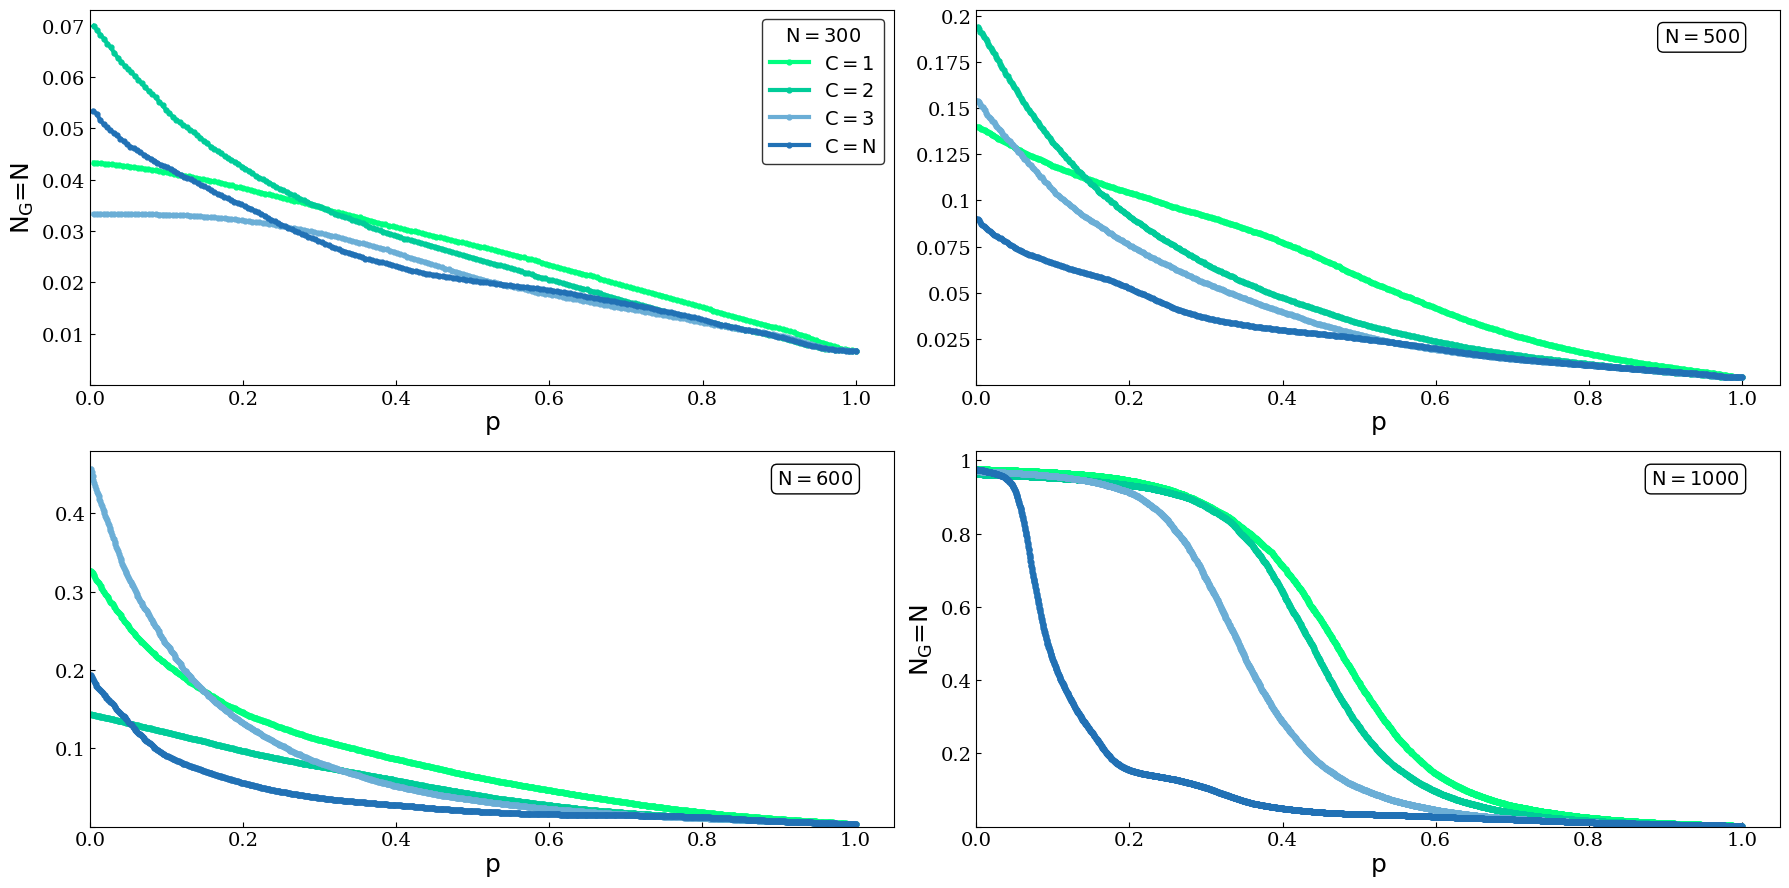

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 🎨 Estilo
# ============================================================
def set_fallback_cm_fonts():
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "mathtext.fontset": "cm",
        "mathtext.rm": "serif",
        "mathtext.it": "serif:italic",
        "mathtext.bf": "serif:bold",
    })

# ============================================================
# 📂 Carregar e empilhar CSVs
# ============================================================
def load_simulation_data(N, C, attack_mode="random", drop_node=True):
    """
    Carrega todos os CSVs de uma configuração (N, C, modo ataque),
    empilha em um DataFrame e retorna lista de DFs.
    """
    data_dir = f'./data/N{N}/{attack_mode}/C{C}/'
    dfs = []

    if not os.path.exists(data_dir):
        print(f"[AVISO] Diretório não encontrado: {data_dir}")
        return []

    for file_name in os.listdir(data_dir):
        if not file_name.endswith(".csv"):
            continue
        df = pd.read_csv(
            os.path.join(data_dir, file_name), 
            sep=' ', 
            names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"]
        )
        if drop_node:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)
    
    return dfs

def compute_average_curves(N, C, attack_mode="random"):
    """
    Empilha todos os CSVs da configuração e retorna
    curva média + desvio padrão agrupada por p.
    """
    dfs = load_simulation_data(N, C, attack_mode=attack_mode)
    if not dfs:
        return pd.DataFrame()

    combined_df = pd.concat(dfs)
    mean_df = combined_df.groupby("p").mean()
    std_df = combined_df.groupby("p").std()

    final_df = mean_df.merge(std_df, on="p", suffixes=("", "_std")).reset_index()
    return final_df

# ============================================================
# 📊 Subplot
# ============================================================
def plot_m1_subplot(ax, N, attack_mode="random", show_legend=False):
    set_fallback_cm_fonts()

    cmap = plt.colormaps.get_cmap('winter')
    styles = {
        'C=1': {'color': cmap(1.0), 'marker': 'o'},   # ε = 1.0
        'C=2': {'color': cmap(0.8), 'marker': 'o'},   # ε = 0.75
        'C=3': {'color': '#6BAED6', 'marker': 'o'},   # ε = 0.5
        'C=N': {'color': '#2171B5', 'marker': 'o'},   # ε = 0.25
    }

    # Carregar as curvas médias
    C1_df = compute_average_curves(N, 1, attack_mode)
    C2_df = compute_average_curves(N, 2, attack_mode)
    C3_df = compute_average_curves(N, 3, attack_mode)
    CN_df = compute_average_curves(N, N, attack_mode)

    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    def safe_plot(df, label, style):
        if df.empty or "p" not in df or "m1" not in df:
            print(f"[AVISO] Dados ausentes para {label} em N={N}")
            return
        ax.plot(df["p"], df["m1"], label=label, **style,
                linewidth=3, markersize=3.5)

    safe_plot(C1_df, r"$C=1$", styles['C=1'])
    safe_plot(C2_df, r"$C=2$", styles['C=2'])
    safe_plot(C3_df, r"$C=3$", styles['C=3'])
    safe_plot(CN_df, r"$C=N$", styles['C=N'])

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$" if N in (300, 1000) else "", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: '' if val == 0 else f'{val:g}'))
    ax.grid(False)

    if show_legend:
        ax.legend(
            fontsize=14,
            title=rf"$N={N}$",
            title_fontsize=14,
            frameon=True,
            fancybox=True,
            edgecolor='black',
            loc='upper right'
        )
    else:
        ax.text(
            0.95, 0.95, rf"$N={N}$",
            transform=ax.transAxes,
            fontsize=14,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black')
        )

# ============================================================
# 🖼️ Layout
# ============================================================
def plot_m1_multi_layout(attack_mode="random"):
    Ns = [300, 500, 600, 1000]
    fig, axs = plt.subplots(2, 2, figsize=(18, 9))

    for ax, N in zip(axs.flat, Ns):
        plot_m1_subplot(ax, N, attack_mode=attack_mode, show_legend=(N == 300))

    fig.tight_layout()
    fig.savefig(f"attack_{attack_mode}_spp.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

# ============================================================
# 🚀 Main
# ============================================================
if __name__ == "__main__":
    plot_m1_multi_layout("random")
